# Urban ML Pipeline — Analysis

This notebook analyzes the dataset generated by `run_pipeline.py` and runs the full ML workflow required by the DEML course:

1. **EDA** — Class distribution, boxplots, correlations, SOM
2. **Dimensionality reduction** — PCA (biplot), ICA (mixing matrix), t-SNE
3. **Encoding experiments** — Scaling (StandardScaler vs MinMaxScaler vs none) and target encoding
4. **Supervised classification** — Logistic Regression (baseline), XGBoost, Random Forest, SVC, ANN
5. **Ablation study + tuning** — Remove ONE feature at a time, GridSearchCV
6. **Clustering** — K-Means with elbow + silhouette
7. **Geographic heatmaps** — Spatial visualization of predictions per city
8. **Cross-city comparison** — Feature means, accuracy, class balance across cities
9. **Binary vs 3-Class** — Compare with and without Mixed-Use
10. **Transfer Learning** — Train on Ground Truth cities, predict on OSM-Only cities

### Setup — Imports and Configuration

Loads all required libraries. Optional imports (xgboost, tensorflow, minisom, folium) are in `try/except` blocks — if not installed, the notebook keeps running and simply skips those sections.

Also imports pipeline constants from `config.py`: feature list, class mapping, neural network configuration, etc.

In [2]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.pipeline import Pipeline

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed — skipping XGBoost")

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except ImportError:
    HAS_TF = False
    print("tensorflow not installed — skipping ANN")

try:
    from minisom import MiniSom
    HAS_SOM = True
except ImportError:
    HAS_SOM = False
    print("minisom not installed — run: pip install minisom")

try:
    import folium
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False
    print("folium not installed — skipping interactive maps")

# Import pipeline config
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from config import FEATURE_COLS, get_class_map, CITY_REGISTRY, ANN_CONFIG, KMEANS_MAX_K, TSNE_PERPLEXITY

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
os.makedirs("outputs", exist_ok=True)
print("Setup complete")

tensorflow not installed — skipping ANN
minisom not installed — run: pip install minisom
Setup complete


## 0. Data Loading

Loads the combined CSV with all cities. This file is generated by `run_pipeline.py` and contains one row per grid cell (150m x 150m) with its features and the `zone_type` column (the Y label).

**What to look for in the output:**
- Total number of rows (each row = one grid cell)
- List of included cities
- Available column names

### Dataset Preparation

Applies class mapping (`Commercial`, `Mixed-Use` → `Residential`, etc.), selects the features, scales with `StandardScaler`, encodes labels, and splits into train/test (80/20).

**What to look for in the output:**
- **Class distribution:** How many cells per class? If there is heavy imbalance (>5:1), models need `class_weight="balanced"`.
- **Missing features:** If a WARNING appears, some feature was not generated by the pipeline.
- **N_FOLDS:** If the smallest class has few samples, CV automatically uses fewer folds.
- **Train/Test split:** Should be approximately 80/20.

In [3]:
DATA_PATH = r"C:\Users\User\Desktop\00-MaCAD\DataEncoding\OSMnx-data-scraper\ahmad\Final_Pipeline_ShallowLearning\all_cities_combined.csv"
assert os.path.exists(DATA_PATH), f"Run `python run_pipeline.py` first to generate {DATA_PATH}"

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df_raw)} rows, {len(df_raw.columns)} columns")
print(f"Cities: {df_raw['city'].unique().tolist()}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Loaded 60278 rows, 19 columns
Cities: ['NYC', 'Philadelphia', 'DC', 'Chicago', 'SF', 'LA']
Columns: ['city', 'cell_id', 'cell_lat', 'cell_lon', 'zone_type', 'cell_lot_count', 'amenity_density', 'amenity_ratio_food_drink', 'avg_floors', 'avg_yearbuilt', 'total_bldg_area', 'building_count', 'landuse_entropy', 'shop_density_km2', 'office_density', 'road_density_primary', 'transit_stop_density', 'intersection_density', 'nightlife_density']


,city,cell_id,cell_lat,cell_lon,zone_type,cell_lot_count,amenity_density,amenity_ratio_food_drink,avg_floors,avg_yearbuilt,total_bldg_area,building_count,landuse_entropy,shop_density_km2,office_density,road_density_primary,transit_stop_density,intersection_density,nightlife_density
0,NYC,r0011_c0018,40.701792,-74.013677,Open Space,3,10844.44,0.0451,NaN,NaN,0.0,3.0,-0.0000,88.89,44.44,7.66,933.33,355.56,44.44
1,NYC,r0012_c0018,40.703143,-74.013677,Commercial,5,8844.44,0.0201,28.9,1930.0,2142087.0,4.0,0.3323,88.89,44.44,6.74,266.67,222.22,0.00
2,NYC,r0012_c0019,40.703143,-74.011893,Commercial,18,2177.78,0.3061,16.1,1958.0,1387382.0,10.0,1.0703,355.56,44.44,0.00,222.22,266.67,88.89
3,NYC,r0012_c0020,40.703143,-74.010108,Residential,11,4755.56,0.0841,6.6,1873.0,1281484.0,20.0,1.9788,222.22,177.78,0.00,88.89,88.89,0.00
4,NYC,r0012_c0021,40.703143,-74.008324,Commercial,3,2977.78,0.0000,29.0,1942.0,3602735.0,2.0,0.3506,0.00,44.44,0.00,0.00,133.33,0.00


In [4]:
# Apply class mapping
class_map = get_class_map()
df = df_raw[df_raw["zone_type"].isin(class_map)].copy()
df["label"] = df["zone_type"].map(class_map)
print(f"After class mapping: {len(df)} rows")
print(f"Class distribution:\n{df['label'].value_counts()}")

# Feature matrix
available_features = [f for f in FEATURE_COLS if f in df.columns]
missing = [f for f in FEATURE_COLS if f not in df.columns]
if missing:
    print(f"WARNING: Missing features: {missing}")
print(f"Using {len(available_features)} features: {available_features}")

X = df[available_features].fillna(0).values
y = df["label"].values
cities = df["city"].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_.tolist()
print(f"Classes: {class_names}")

# Determine safe number of CV folds based on smallest class
min_class_count = pd.Series(y_encoded).value_counts().min()
N_FOLDS = min(5, min_class_count)
if N_FOLDS < 5:
    print(f"WARNING: Smallest class has {min_class_count} samples — using {N_FOLDS}-fold CV instead of 5")

# Stratified split (need at least 2 per class)
if min_class_count >= 2:
    X_train, X_test, y_train, y_test, cities_train, cities_test = train_test_split(
        X_scaled, y_encoded, cities, test_size=0.2, random_state=42, stratify=y_encoded
    )
else:
    print("WARNING: Class too small for stratified split — using random split")
    X_train, X_test, y_train, y_test, cities_train, cities_test = train_test_split(
        X_scaled, y_encoded, cities, test_size=0.2, random_state=42
    )
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

After class mapping: 53391 rows
Class distribution:
label
Residential    47974
Commercial      5417
Name: count, dtype: int64
Using 13 features: ['amenity_density', 'amenity_ratio_food_drink', 'avg_floors', 'avg_yearbuilt', 'building_count', 'total_bldg_area', 'landuse_entropy', 'shop_density_km2', 'office_density', 'road_density_primary', 'transit_stop_density', 'intersection_density', 'nightlife_density']
Classes: ['Commercial', 'Residential']
Train: 42712, Test: 10679


### Boxplots — Distribution of Each Feature by Class

One boxplot per feature, separated by class (Commercial vs Residential).

**How to read a boxplot:**
- The **box** contains the central 50% of the data (Q1 to Q3)
- The **green line** inside the box = median
- The **whiskers** extend to 1.5x the interquartile range
- **Circles** outside the whiskers = outliers

**What to look for:**
- If the Commercial and Residential boxes **do not overlap** → that feature separates the classes well (good feature)
- If they overlap a lot → that feature alone does not distinguish the classes (but may still be useful in combination with others)
- **Outliers** in one class but not the other → the feature captures extreme behavior in that class

### Correlation Matrix

Shows the Pearson coefficient (r) between each pair of features. Values from -1 to 1.

**How to interpret:**
- **r > 0.7** (dark red): Highly correlated features → probably redundant (measure the same thing). Candidates to remove one of the two.
- **r ≈ 0** (white): Independent features → each contributes different information. Ideal.
- **r < -0.7** (dark blue): Strong negative correlation → also redundant (one is the "inverse" of the other).
- **The diagonal** always has 1.0 (each feature is perfectly correlated with itself).

**Rule of thumb:** If no pair exceeds |r| > 0.7, all features are sufficiently independent.

## 1. Exploratory Data Analysis (EDA)

EDA is the mandatory first step before training any model. Its goal is to **understand the data visually** before making decisions.

**Professor's rule:** "Visualize the data BEFORE training — plots, plots, plots."

In this section we generate:
- **Class distribution** — Is the dataset balanced? How many cells per class and per city?
- **Feature boxplots** — Which features separate the classes well? Which ones overlap?
- **Correlation matrix** — Are there redundant features (r > 0.7)? Which are independent?

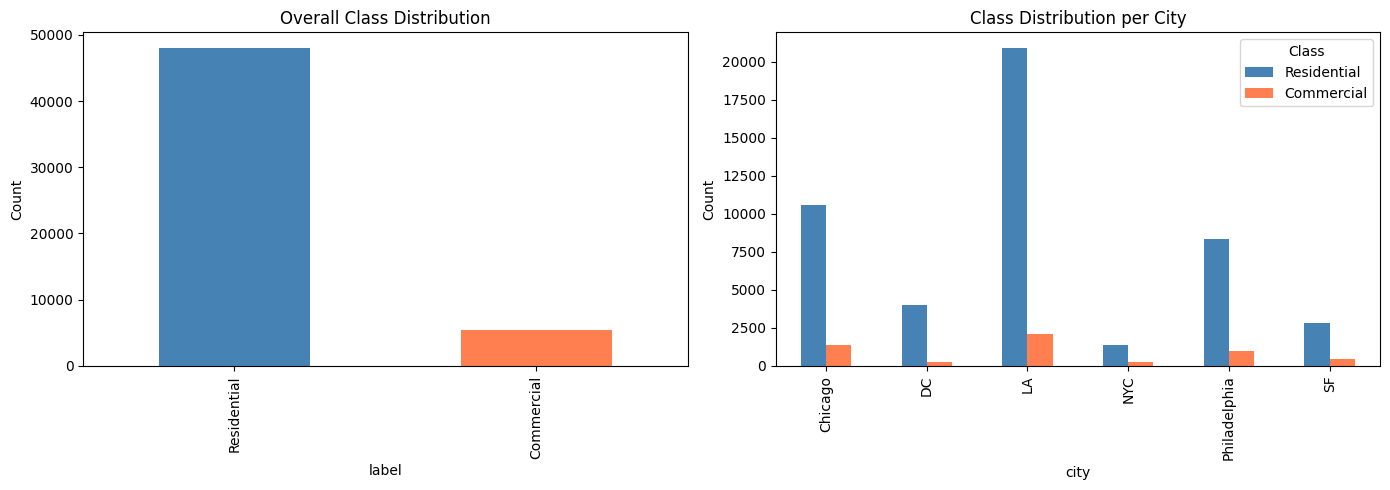

In [5]:
# Class distribution per city
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create color mapping for consistency across both charts (flipped: Residential=steelblue, Commercial=coral)
color_map = {"Residential": "steelblue", "Commercial": "coral"}

# Left chart: Overall distribution
vc = df["label"].value_counts()
colors_left = [color_map[label] for label in vc.index]
vc.plot.bar(ax=axes[0], color=colors_left)
axes[0].set_title("Overall Class Distribution")
axes[0].set_ylabel("Count")

# Right chart: Distribution per city (reordered: Residential first, then Commercial)
ct = pd.crosstab(df["city"], df["label"])
ct = ct[["Residential", "Commercial"]]  # Reorder columns
colors_right = [color_map[col] for col in ct.columns]
ct.plot.bar(ax=axes[1], color=colors_right)
axes[1].set_title("Class Distribution per City")
axes[1].set_ylabel("Count")
axes[1].legend(title="Class")

plt.tight_layout()
plt.savefig("outputs/01_class_distribution.png", bbox_inches="tight")
plt.show()

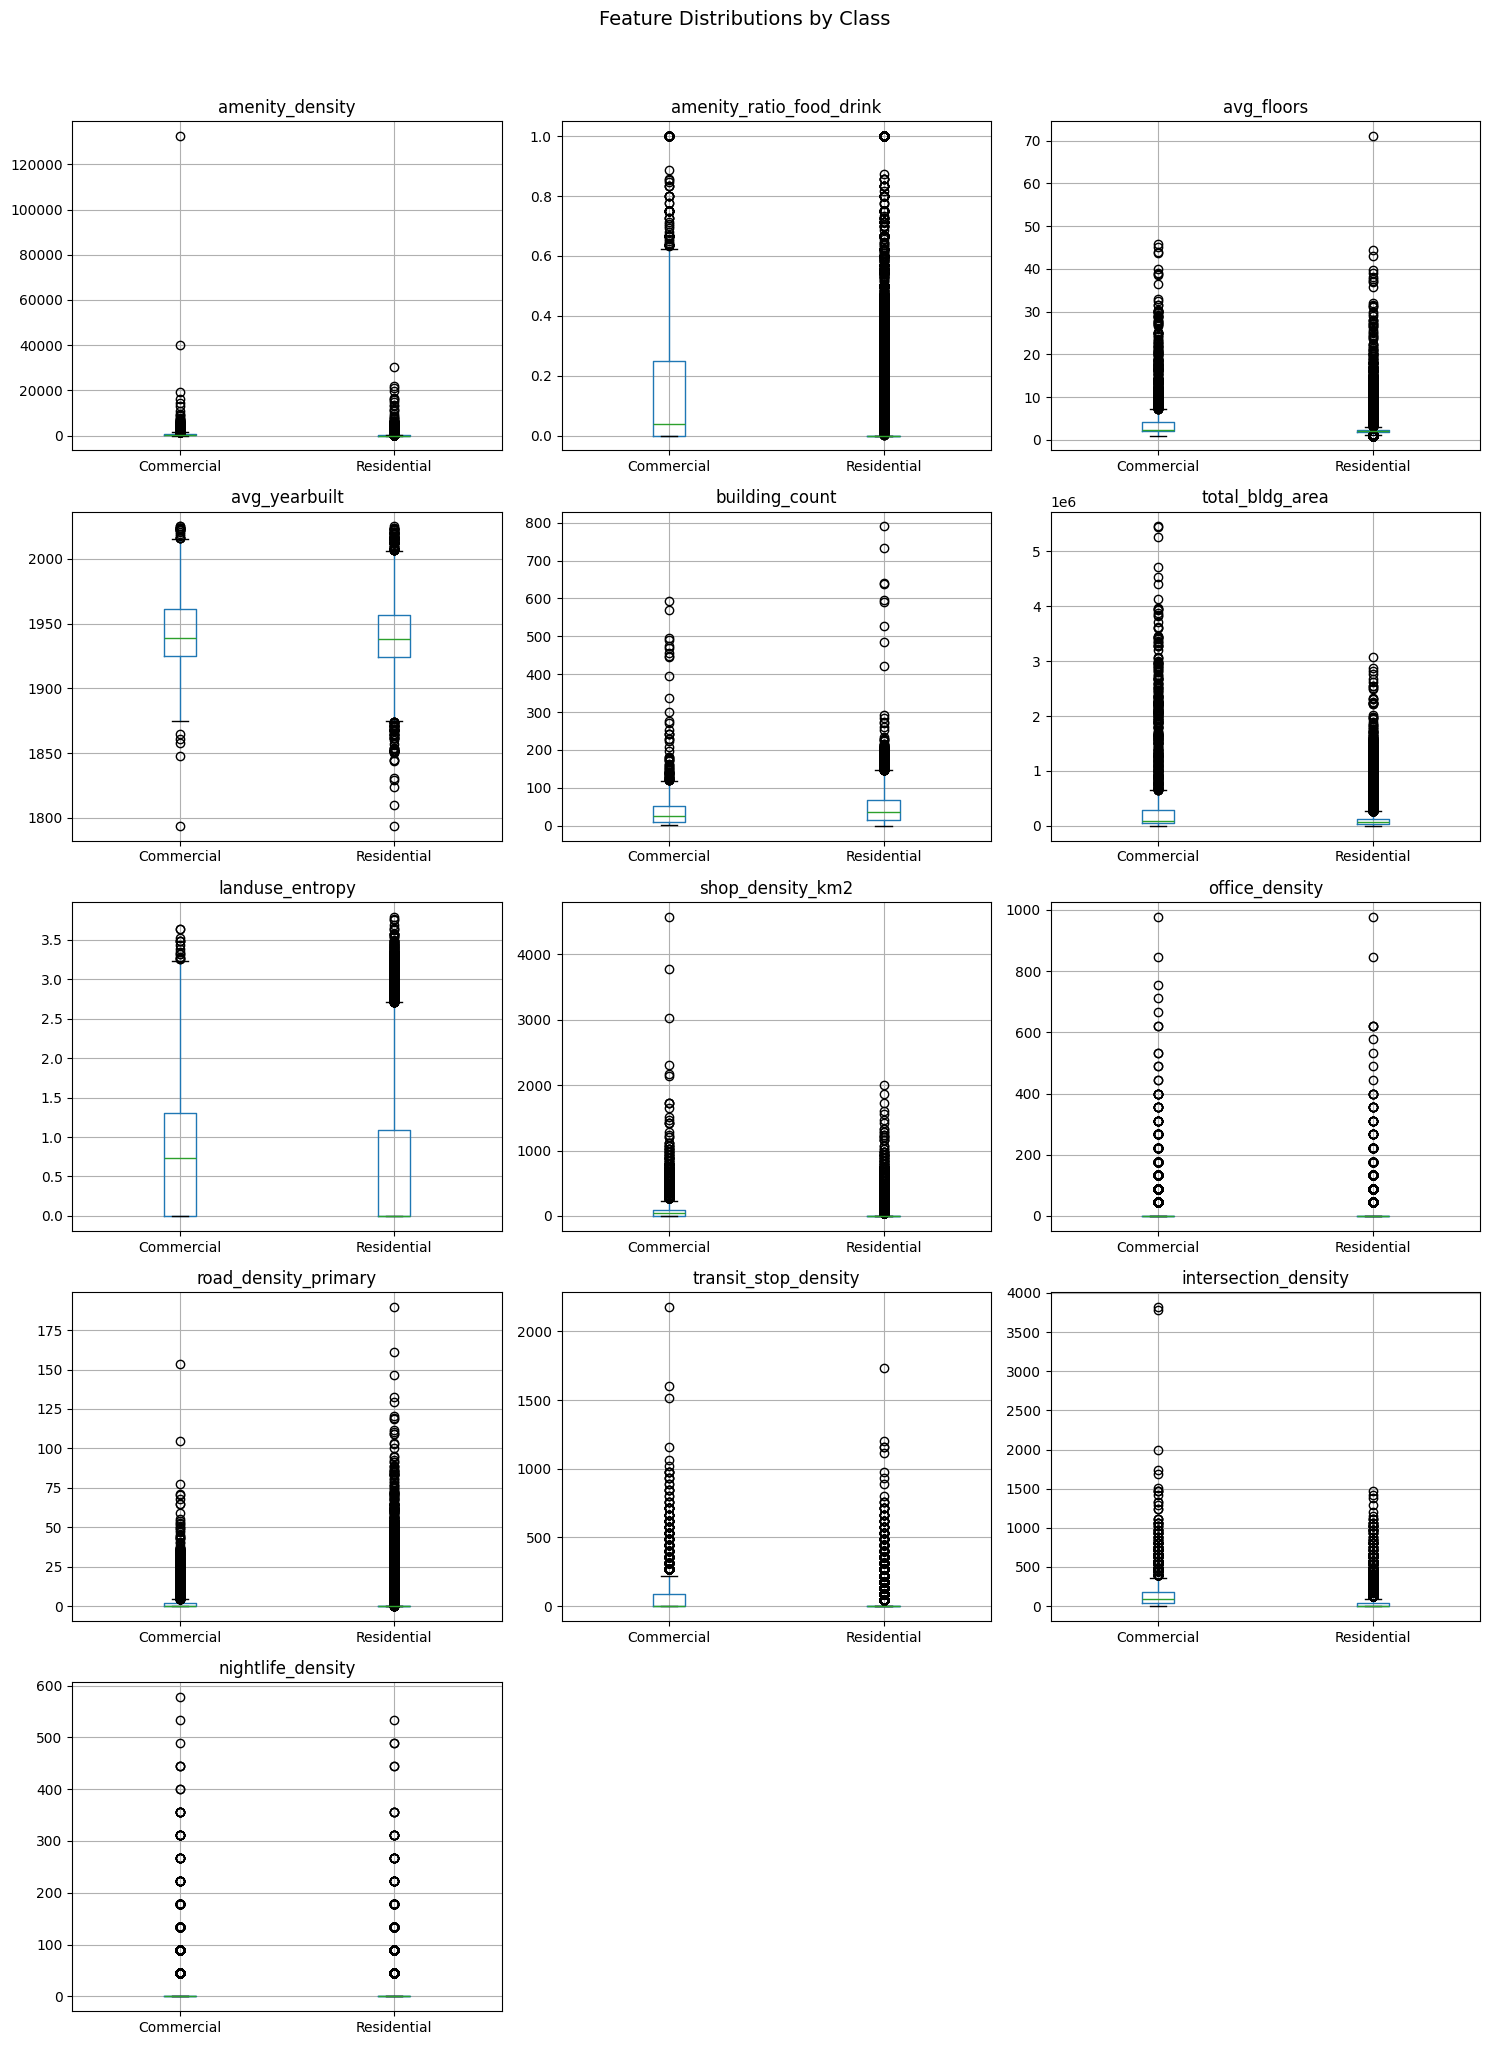

In [6]:
# Feature boxplots
n_feat = len(available_features)
n_cols_plot = 3
n_rows_plot = (n_feat + n_cols_plot - 1) // n_cols_plot
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(15, 4 * n_rows_plot))
axes = axes.flatten()

for i, feat in enumerate(available_features):
    df.boxplot(column=feat, by="label", ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel("")

for i in range(n_feat, len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Feature Distributions by Class", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("outputs/02_feature_boxplots.png", bbox_inches="tight")
plt.show()

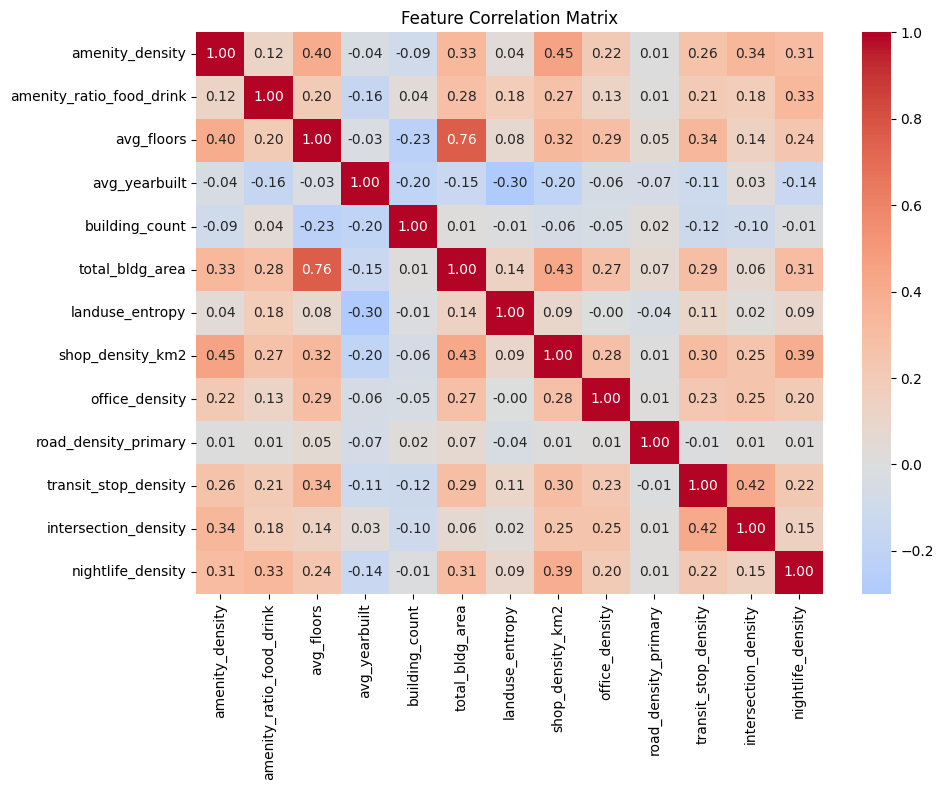

In [7]:
# Correlation heatmap
corr = df[available_features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("outputs/03_correlation_heatmap.png", bbox_inches="tight")
plt.show()

### 4.2 XGBoost (Shallow, Gradient Boosting)

XGBoost builds decision trees **sequentially**: each new tree tries to correct the errors of the previous one. It is generally the best shallow model for tabular data.

**How to interpret the Feature Importance:**
- The longest bar = the feature XGBoost uses most to make decisions
- High importance features → these truly discriminate between classes
- Low importance features → may be noise (candidates for the ablation study)
- Compare with Random Forest importance — if both agree on the top features, the signal is robust

XGBoost Results:
              precision    recall  f1-score   support

  Commercial       0.63      0.27      0.37      1083
 Residential       0.92      0.98      0.95      9596

    accuracy                           0.91     10679
   macro avg       0.78      0.62      0.66     10679
weighted avg       0.89      0.91      0.89     10679



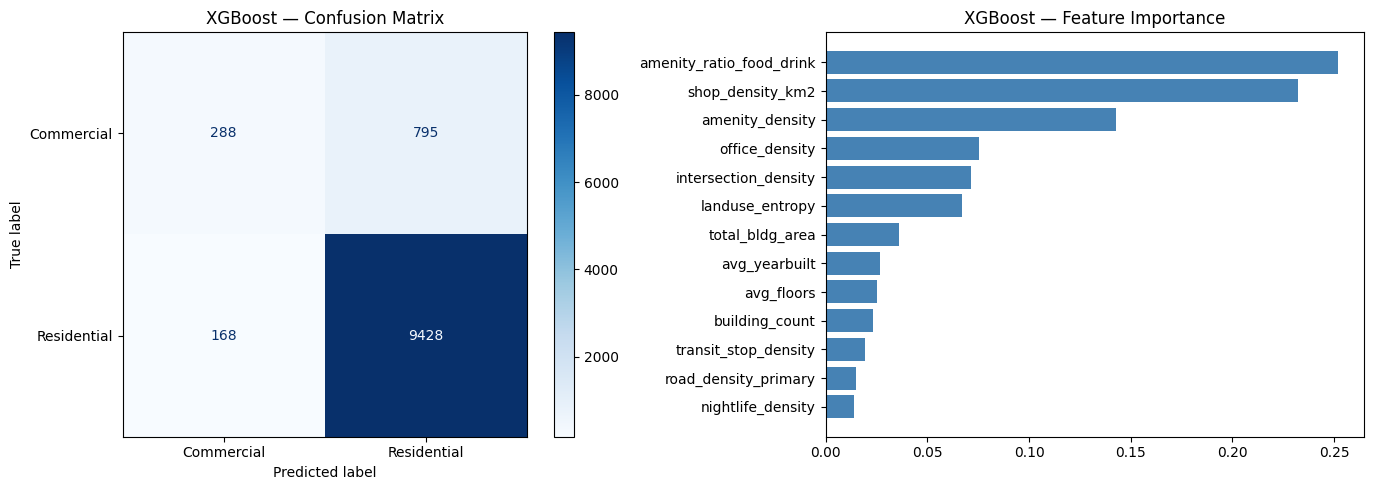

In [8]:
if HAS_XGB:
    xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                        random_state=42, eval_metric="mlogloss")
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)

    print("XGBoost Results:")
    print(classification_report(y_test, y_pred_xgb, target_names=class_names))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, display_labels=class_names, ax=axes[0], cmap="Blues")
    axes[0].set_title("XGBoost — Confusion Matrix")

    importances = xgb.feature_importances_
    idx = np.argsort(importances)
    axes[1].barh([available_features[i] for i in idx], importances[idx], color="steelblue")
    axes[1].set_title("XGBoost — Feature Importance")
    plt.tight_layout()
    plt.savefig("outputs/09_xgb_results.png", bbox_inches="tight")
    plt.show()
else:
    print("Skipping XGBoost (not installed)")
    y_pred_xgb = None

### 4.3 Random Forest (Shallow, Tree Ensemble)

Random Forest trains many decision trees **in parallel**, each with a random sample of data and features. The final prediction is the majority vote of all trees.

**Advantages:** Robust to overfitting, provides feature importance, does not require scaling.

**How to interpret the Feature Importance:**
- Measures how much each feature reduces impurity (Gini) averaged across all trees
- Compare the ranking with XGBoost: if both agree on the top 3 features → robust signal
- If they differ a lot → there are complex interactions that each model exploits differently

Random Forest Results:
              precision    recall  f1-score   support

  Commercial       0.32      0.74      0.44      1083
 Residential       0.97      0.82      0.89      9596

    accuracy                           0.81     10679
   macro avg       0.64      0.78      0.67     10679
weighted avg       0.90      0.81      0.84     10679



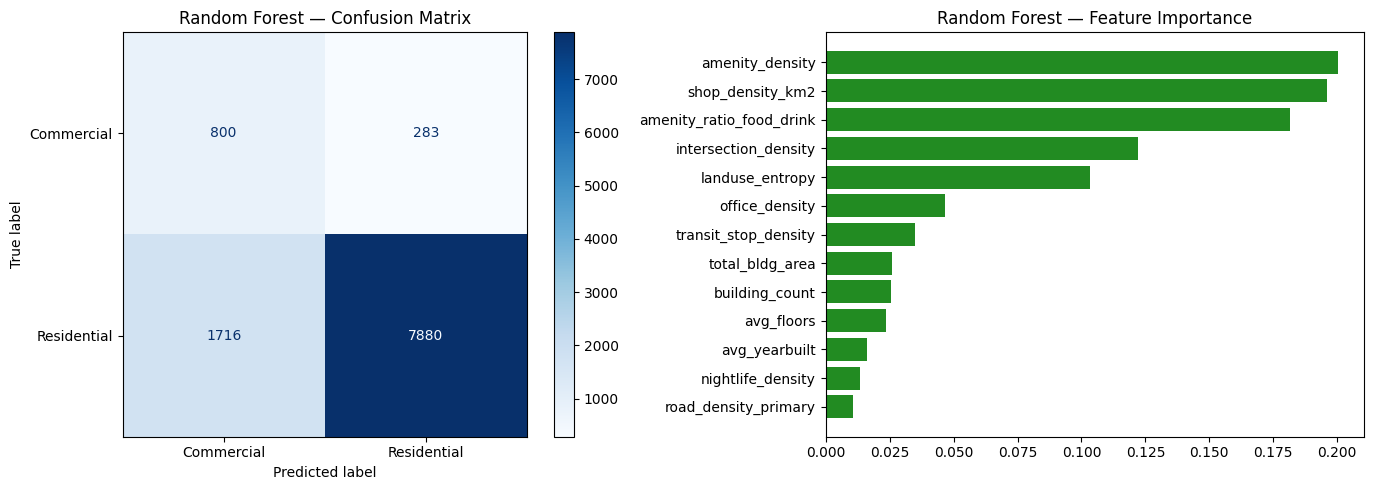

In [9]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=class_names, ax=axes[0], cmap="Blues")
axes[0].set_title("Random Forest — Confusion Matrix")

importances = rf.feature_importances_
idx = np.argsort(importances)
axes[1].barh([available_features[i] for i in idx], importances[idx], color="forestgreen")
axes[1].set_title("Random Forest — Feature Importance")
plt.tight_layout()
plt.savefig("outputs/10_rf_results.png", bbox_inches="tight")
plt.show()

### 4.4 Support Vector Classification (SVC — Shallow)

SVC finds the **hyperplane** that maximizes the distance (margin) between classes. The kernel transforms the data to a higher-dimensional space where they can be linearly separable.

**Kernels tested:**
- **linear**: Straight decision boundary. Similar to Logistic Regression.
- **rbf** (Radial Basis Function): Curved boundary. Captures moderate nonlinearities.
- **poly** (Polynomial): Polynomial boundary. Captures feature interactions.

**How to interpret:**
- If linear kernel is best → the problem is linearly separable (LR would be enough)
- If rbf or poly is best → there are nonlinear relationships the linear models miss
- Compare with LR accuracy: the improvement measures "how nonlinear" the data is

Logistic Regression Results:
              precision    recall  f1-score   support

  Commercial       0.30      0.66      0.42      1083
 Residential       0.96      0.83      0.89      9596

    accuracy                           0.81     10679
   macro avg       0.63      0.74      0.65     10679
weighted avg       0.89      0.81      0.84     10679



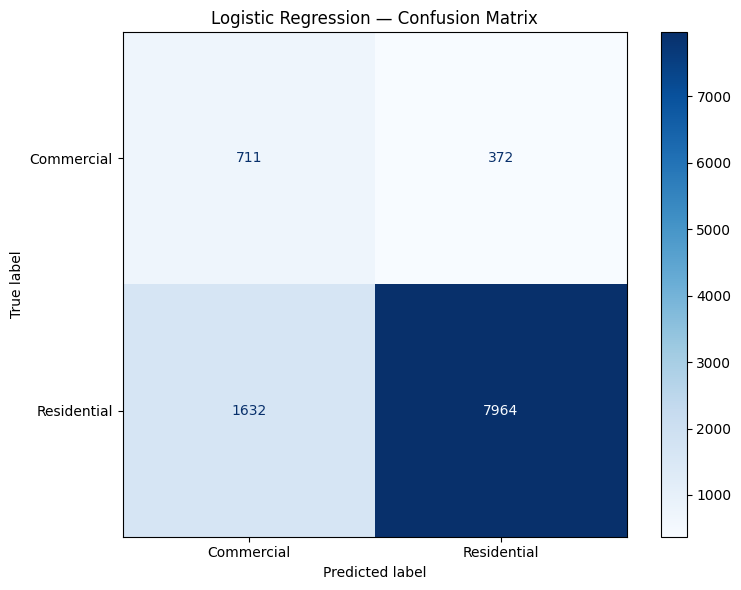

Saved: outputs/08_lr_results.png


In [12]:
# Logistic Regression (baseline — linear model)
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=class_names, ax=ax, cmap="Blues")
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/08_lr_results.png", bbox_inches="tight")
plt.show()
print("Saved: outputs/08_lr_results.png")


### Export Predictions

Uses the best model (Random Forest) to predict ALL cells in the dataset (not just the test set). Saves a CSV per city with predictions, which will be used by the heatmap and comparison sections.

The accuracy reported here is **re-substitution** (prediction on data the model already saw during training), so it will be higher than the test set accuracy. The true generalization accuracy is the test set accuracy reported above.

SVC: subsampled 10000 from 42712 training samples
SVC (rbf): accuracy = 0.826
SVC (linear): accuracy = 0.831
SVC (poly): accuracy = 0.862
Best kernel: poly
              precision    recall  f1-score   support

  Commercial       0.36      0.48      0.41      1083
 Residential       0.94      0.91      0.92      9596

    accuracy                           0.86     10679
   macro avg       0.65      0.69      0.67     10679
weighted avg       0.88      0.86      0.87     10679



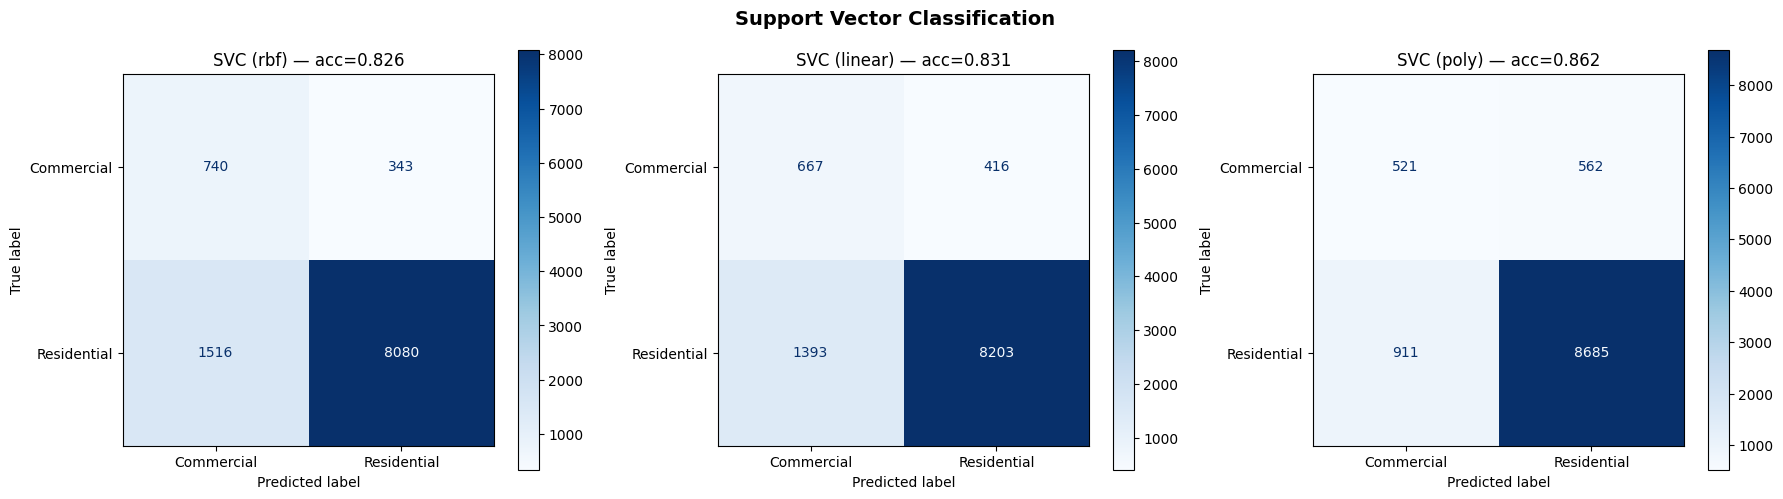

Saved: outputs/11_svc_results.png


In [10]:
# SVC training (subsample for large datasets — SVC is O(n²))
SVC_TRAIN_MAX = 10000
if len(X_train) > SVC_TRAIN_MAX:
    rng_svc = np.random.RandomState(42)
    idx_svc = rng_svc.choice(len(X_train), SVC_TRAIN_MAX, replace=False)
    X_train_svc = X_train[idx_svc]
    y_train_svc = y_train[idx_svc]
    print(f"SVC: subsampled {SVC_TRAIN_MAX} from {len(X_train)} training samples")
else:
    X_train_svc = X_train
    y_train_svc = y_train

svc_results = {}
for kernel in ["rbf", "linear", "poly"]:
    svc = SVC(kernel=kernel, class_weight="balanced", random_state=42)
    svc.fit(X_train_svc, y_train_svc)
    y_pred_svc = svc.predict(X_test)
    acc = accuracy_score(y_test, y_pred_svc)
    svc_results[kernel] = {"accuracy": acc, "y_pred": y_pred_svc}
    print(f"SVC ({kernel}): accuracy = {acc:.3f}")

best_kernel = max(svc_results, key=lambda k: svc_results[k]["accuracy"])
print("Best kernel:", best_kernel)
print(classification_report(y_test, svc_results[best_kernel]["y_pred"],
                            target_names=class_names, zero_division=0))

# Confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, kernel in enumerate(["rbf", "linear", "poly"]):
    ConfusionMatrixDisplay.from_predictions(
        le.inverse_transform(y_test),
        le.inverse_transform(svc_results[kernel]["y_pred"]),
        display_labels=class_names, ax=axes[i], cmap="Blues"
    )
    axes[i].set_title(f"SVC ({kernel}) — acc={svc_results[kernel]['accuracy']:.3f}")
plt.suptitle("Support Vector Classification", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/11_svc_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/11_svc_results.png")


### 4.6 Model Comparison

Summary table with the accuracy of each model on the test set.

**How to interpret:**
- The model with the highest accuracy is the "winner", but the difference matters:
  - <2% difference → they are equivalent, choose the simplest/most interpretable one
  - >5% difference → the more complex model is justified
- Compare LR (linear baseline) vs the rest: **the accuracy jump** measures how much nonlinearity exists in your data
- If all models give ~same result → the ceiling is in the data, not the algorithm

**Remember:** Accuracy > 80% is the professor's minimum target.

              Model  Accuracy
            XGBoost  0.909823
         SVC (poly)  0.862066
      Random Forest  0.812810
Logistic Regression  0.812342


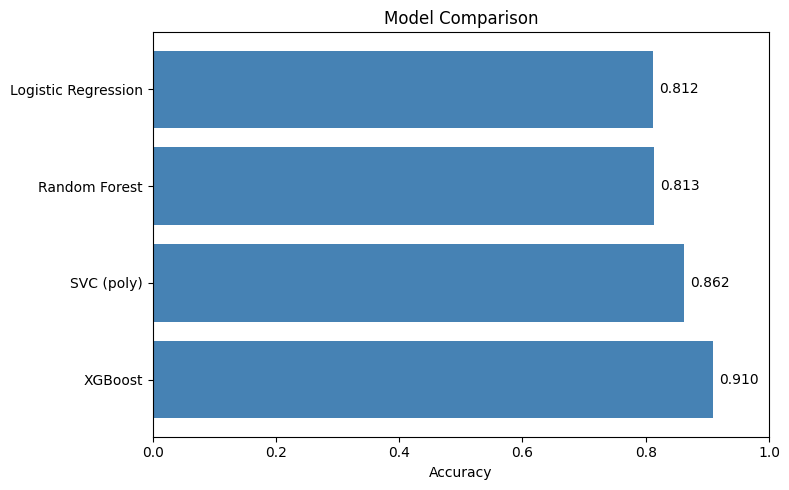

In [13]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    f"SVC ({best_kernel})": svc_results[best_kernel]["accuracy"],
}
if HAS_XGB and y_pred_xgb is not None:
    results["XGBoost"] = accuracy_score(y_test, y_pred_xgb)
if HAS_TF and acc_ann is not None:
    results["ANN (Keras)"] = acc_ann

df_results = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
df_results = df_results.sort_values("Accuracy", ascending=False)
print(df_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_results["Model"], df_results["Accuracy"], color="steelblue")
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy")
ax.set_title("Model Comparison")
for i, (_, row) in enumerate(df_results.iterrows()):
    ax.text(row["Accuracy"] + 0.01, i, f"{row['Accuracy']:.3f}", va="center")
plt.tight_layout()
plt.savefig("outputs/13_model_comparison.png", bbox_inches="tight")
plt.show()

### SVC Tuning + Updated Comparison

Same GridSearchCV process but for SVC (kernel, C, gamma). At the end, shows an updated comparison table that includes both default and tuned models.

**How to interpret the final table:** If "RF (tuned)" or "SVC (tuned)" clearly surpass their default versions, the tuning was worthwhile. If not, the defaults were already good.

In [ ]:
# Export predictions using best supervised model (RF by default)
best_model = rf
y_pred_all = best_model.predict(X_scaled)
df["predicted"] = le.inverse_transform(y_pred_all)
df["correct"] = df["predicted"] == df["label"]

for city_key in df["city"].unique():
    city_dir = f"csv/{city_key}"
    os.makedirs(city_dir, exist_ok=True)
    df_city = df[df["city"] == city_key].copy()
    pred_path = f"{city_dir}/07_predictions.csv"
    df_city.to_csv(pred_path, index=False, encoding="utf-8")
    acc = df_city["correct"].mean()
    print(f"{city_key}: {acc:.3f} accuracy ({len(df_city)} cells) -> {pred_path}")

## 5. Ablation Study & Hyperparameter Tuning

**Professor's rule:** "Change ONE variable at a time. Never change several things and say 'it improved'."

Two different experiments:

**Ablation Study (Section 5.1):** Remove ONE feature at a time and measure how much accuracy changes.
- If accuracy **drops** a lot without the feature → it was important
- If accuracy **rises** or does not change → it was noise and you can remove it
- This answers the professor's question: "How do you know the features you chose are the right ones?"

**Hyperparameter Tuning (Section 5.2):** Try different model configurations and find the optimal combination using GridSearchCV.

### 5.1 Feature Ablation Study

Process: for each feature, we remove it from the dataset and retrain the model (Random Forest with cross-validation). We measure the accuracy without that feature and calculate the "drop" compared to the baseline (all features).

**How to interpret the chart:**
- **Red bars (positive):** Removing that feature LOWERS accuracy → the feature is important. The longer the bar, the more important.
- **Green bars (negative):** Removing that feature RAISES accuracy → the feature was noise or confused the model. Candidate for removal.
- The feature with the longest red bar = the most important feature in the model

In [ ]:
# Ablation: remove one feature at a time, measure accuracy change
print("Feature Ablation Study (Random Forest)")
print("=" * 60)

# Baseline accuracy with all features
baseline_acc = cross_val_score(
    RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    X_scaled, y_encoded, cv=StratifiedKFold(N_FOLDS), scoring="accuracy"
).mean()
print(f"Baseline (all {len(available_features)} features): {baseline_acc:.4f}\n")

ablation_results = {}
for feat_idx, feat_name in enumerate(available_features):
    # Remove this feature
    X_ablated = np.delete(X_scaled, feat_idx, axis=1)
    acc = cross_val_score(
        RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
        X_ablated, y_encoded, cv=StratifiedKFold(N_FOLDS), scoring="accuracy"
    ).mean()
    drop = baseline_acc - acc
    ablation_results[feat_name] = {"accuracy": acc, "drop": drop}
    direction = "DROP" if drop > 0 else "GAIN"
    print(f"  Without {feat_name:<25s} acc={acc:.4f}  ({direction}: {abs(drop):.4f})")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
features_sorted = sorted(ablation_results, key=lambda f: ablation_results[f]["drop"], reverse=True)
drops = [ablation_results[f]["drop"] for f in features_sorted]
colors = ["red" if d > 0 else "green" for d in drops]
ax.barh(features_sorted, drops, color=colors, alpha=0.7)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Accuracy Drop (positive = feature is important)")
ax.set_title("Feature Ablation — Impact on Accuracy")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/14_ablation_study.png", bbox_inches="tight")
plt.show()

print(f"\nMost important: {features_sorted[0]} (drop = {ablation_results[features_sorted[0]]['drop']:.4f})")
print(f"Least important: {features_sorted[-1]} (drop = {ablation_results[features_sorted[-1]]['drop']:.4f})")

### Interactive Maps (Folium)

Generates an interactive HTML map per city using Folium (based on Leaflet.js). You can click on each cell to see its ID, prediction, and actual label.

Maps are saved to `outputs/{city}/heatmap.html` — open them in the browser to explore.

### 5.2 Hyperparameter Tuning (GridSearchCV)

`GridSearchCV` tests **all combinations** of hyperparameters you give it and reports which one works best.

**For Random Forest, we test:**
- `n_estimators`: [50, 100, 200] — number of trees
- `max_depth`: [4, 8, 12, None] — maximum depth of each tree
- `min_samples_leaf`: [1, 3, 5] — minimum samples per leaf

**For SVC, we test:**
- `kernel`: [rbf, linear, poly] — type of decision boundary
- `C`: [0.1, 1, 10] — regularization strength (high C = less regularization)
- `gamma`: [scale, auto] — influence range of each support vector

**How to interpret:**
- `best_params_`: the winning combination
- `best_score_`: cross-validation accuracy of the winner
- If improvement over defaults is < 1% → do not bother tuning, defaults are fine

In [ ]:
# GridSearch for Random Forest
print("Hyperparameter Tuning — Random Forest (GridSearchCV)")
print("=" * 60)

param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [4, 8, 12, None],
    "min_samples_leaf": [1, 3, 5],
}

cv_folds_tuning = min(3, N_FOLDS)
grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid_rf, cv=StratifiedKFold(cv_folds_tuning), scoring="accuracy",
    n_jobs=-1, verbose=0
)
grid_rf.fit(X_scaled, y_encoded)

print(f"Best params: {grid_rf.best_params_}")
print(f"Best CV accuracy: {grid_rf.best_score_:.4f}")
print(f"Default RF accuracy: {baseline_acc:.4f}")
print(f"Improvement: {grid_rf.best_score_ - baseline_acc:+.4f}")

# Visualize top 10 parameter combinations
results_df = pd.DataFrame(grid_rf.cv_results_)
results_df = results_df.sort_values("rank_test_score").head(10)
fig, ax = plt.subplots(figsize=(10, 5))
labels = [str(p) for p in results_df["params"]]
labels = [l.replace("'", "").replace("{", "").replace("}", "") for l in labels]
ax.barh(range(len(labels)), results_df["mean_test_score"], xerr=results_df["std_test_score"],
        color="steelblue", alpha=0.7)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Mean CV Accuracy")
ax.set_title("Top 10 Hyperparameter Combinations (RF)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/15_tuning_rf.png", bbox_inches="tight")
plt.show()

### Feature Means Comparison Across Cities

Shows the average values of each feature per city in two formats:

**Left plot — Z-score normalized:** Each feature is normalized (global mean = 0, std = 1) so all are comparable on the same scale. Positive values = that city is above the global average for that feature. Negative values = below.

**Right plot — Raw scale:** Original values without normalization. Useful for seeing absolute magnitudes, but features like `total_bldg_area` (~900K) dominate the scale and make others invisible.

**How to interpret:** Cities with similar profiles (same pattern of high/low bars) should behave similarly in the model. If one city has a radically different profile, the model may struggle with it.

In [ ]:
# Binary vs 3-Class Classification Comparison
from config import CLASS_MAP_BINARY, CLASS_MAP_3CLASS

comparison_results = {}

for mode_name, class_map_mode in [("Binary (no Mixed-Use)", CLASS_MAP_BINARY), 
                                   ("3-Class (with Mixed-Use)", CLASS_MAP_3CLASS)]:
    # Apply class mapping
    df_mode = df_raw[df_raw["zone_type"].isin(class_map_mode)].copy()
    df_mode["label"] = df_mode["zone_type"].map(class_map_mode)
    
    if len(df_mode) < 20:
        print(f"  {mode_name}: Not enough data ({len(df_mode)} rows) — skipping")
        continue
    
    X_mode = df_mode[available_features].fillna(0).values
    y_mode = LabelEncoder().fit_transform(df_mode["label"].values)
    class_names_mode = sorted(df_mode["label"].unique())
    
    min_class = pd.Series(y_mode).value_counts().min()
    n_folds_mode = min(5, min_class)
    
    if min_class < 2:
        print(f"  {mode_name}: Smallest class has {min_class} samples — skipping")
        continue
    
    scaler_mode = StandardScaler()
    X_mode_scaled = scaler_mode.fit_transform(X_mode)
    
    # Train Random Forest with cross-validation
    rf_mode = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    scores = cross_val_score(rf_mode, X_mode_scaled, y_mode, 
                             cv=StratifiedKFold(n_folds_mode), scoring="accuracy")
    
    comparison_results[mode_name] = {
        "accuracy": scores.mean(),
        "std": scores.std(),
        "n_samples": len(df_mode),
        "n_classes": len(class_names_mode),
        "class_dist": df_mode["label"].value_counts().to_dict(),
    }
    
    print(f"  {mode_name}: accuracy = {scores.mean():.4f} +/- {scores.std():.4f} "
          f"({len(df_mode)} samples, {len(class_names_mode)} classes)")
    print(f"    Class distribution: {df_mode['label'].value_counts().to_dict()}")

# Plot comparison
if len(comparison_results) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    modes = list(comparison_results.keys())
    accs = [comparison_results[m]["accuracy"] for m in modes]
    stds = [comparison_results[m]["std"] for m in modes]
    
    axes[0].bar(modes, accs, yerr=stds, color=["steelblue", "coral"], capsize=5)
    axes[0].set_ylabel("Accuracy (CV)")
    axes[0].set_title("Binary vs 3-Class Accuracy")
    axes[0].set_ylim(0, 1)
    for i, (m, a) in enumerate(zip(modes, accs)):
        axes[0].text(i, a + stds[i] + 0.02, f"{a:.3f}", ha="center")
    
    # Class distribution comparison
    for i, mode in enumerate(modes):
        dist = comparison_results[mode]["class_dist"]
        axes[1].bar([f"{mode}\n{k}" for k in dist.keys()], dist.values(),
                    color=["steelblue", "coral", "green"][:len(dist)])
    axes[1].set_title("Class Distribution per Mode")
    axes[1].set_ylabel("Count")
    
    plt.tight_layout()
    plt.savefig("outputs/20_binary_vs_3class.png", bbox_inches="tight")
    plt.show()
    
    # Determine winner
    best_mode = max(comparison_results, key=lambda m: comparison_results[m]["accuracy"])
    delta = abs(comparison_results[modes[0]]["accuracy"] - comparison_results[modes[1]]["accuracy"])
    print(f"\nBest mode: {best_mode}")
    print(f"Accuracy difference: {delta:.4f}")
    if delta < 0.02:
        print("Difference < 2% — modes are practically equivalent")
    elif delta < 0.05:
        print("Difference 2-5% — moderate advantage for the winner")
    else:
        print("Difference > 5% — significant advantage for the winner")

## 7. Heatmap — Geographic Visualization

Represents the model predictions **spatially** on the map of each city. Each point is a grid cell (150m x 150m) colored by the predicted class.

**Project step 9:** "Represent evaluation graphically and geometrically — heatmaps showing predictions spatially."

**How to interpret:**
- **Red = Commercial**, **Blue = Residential**
- Predicted commercial zones should match reality (business districts, commercial centers)
- Transitions between zones should be gradual (not random jumps) — indicating the model learned spatial patterns
- Look for "islands" of one class inside the other → potential misclassifications or zones in transition

In [ ]:
HAS_COORDS = "cell_lat" in df.columns and "cell_lon" in df.columns

if HAS_COORDS:
    city_list = sorted(df["city"].unique())
    n_cities = len(city_list)

    fig, axes = plt.subplots(1, n_cities, figsize=(6 * n_cities, 6))
    if n_cities == 1:
        axes = [axes]

    zone_colors = {"Commercial": "red", "Residential": "blue", "Other": "green"}

    for i, city_key in enumerate(city_list):
        df_city = df[df["city"] == city_key]
        ax = axes[i]
        for label in df_city["predicted"].unique():
            mask = df_city["predicted"] == label
            color = zone_colors.get(label, "gray")
            ax.scatter(df_city.loc[mask, "cell_lon"], df_city.loc[mask, "cell_lat"],
                       c=color, s=3, alpha=0.5, label=label)
        ax.set_title(f"{city_key} ({len(df_city)} cells)")
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        ax.legend(markerscale=4, fontsize=8)
        ax.set_aspect("equal")

    plt.suptitle("Predicted Zone Types per City", fontsize=14)
    plt.tight_layout()
    plt.savefig("outputs/17_heatmap_all_cities.png", bbox_inches="tight")
    plt.show()
else:
    city_list = sorted(df["city"].unique())
    print("Skipping spatial heatmap — columns 'cell_lat'/'cell_lon' not found in dataset")
    print(f"Available columns: {list(df.columns)}")

In [ ]:
# Interactive folium maps (one per city)
if HAS_FOLIUM and HAS_COORDS:
    for city_key in city_list:
        df_city = df[df["city"] == city_key]
        center_lat = df_city["cell_lat"].mean()
        center_lon = df_city["cell_lon"].mean()
        m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

        color_map = {"Commercial": "red", "Residential": "blue", "Other": "green"}
        id_col = "cell_id" if "cell_id" in df_city.columns else None
        for _, row in df_city.iterrows():
            cell_label = f"{row[id_col]}: " if id_col else ""
            folium.CircleMarker(
                location=[row["cell_lat"], row["cell_lon"]],
                radius=3,
                color=color_map.get(row["predicted"], "gray"),
                fill=True, fill_opacity=0.6,
                popup=f"{cell_label}{row['predicted']} (actual: {row['label']})"
            ).add_to(m)

        os.makedirs(f"outputs/{city_key}", exist_ok=True)
        map_path = f"outputs/{city_key}/heatmap.html"
        m.save(map_path)
        print(f"Saved interactive map: {map_path}")
elif not HAS_COORDS:
    print("Skipping interactive maps — no coordinate columns")
else:
    print("Skipping interactive maps (folium not installed)")

## 8. Cross-City Comparison

Compares model performance and dataset characteristics across all included cities.

**Three charts:**
1. **Accuracy per City:** In which city does the model perform best/worst? Cities with cleaner data or clearer patterns will have higher accuracy.
2. **Cell Count per City:** How many cells does each city contribute? Cities with more cells dominate the training.
3. **Class Balance per City:** Is the Commercial/Residential imbalance consistent across cities? If one city has 50/50 and another 90/10, the model may be biased toward the more common city's patterns.

---

**Pipeline complete.** All plots saved to `outputs/`.

**Summary of generated files:**
- `outputs/01-03` — EDA (distribution, boxplots, correlation)
- `outputs/03b-03c` — SOM (U-Matrix, component planes)
- `outputs/04-06` — Dimensionality reduction (PCA, ICA, t-SNE)
- `outputs/07` — Encoding/scaling experiment
- `outputs/08-12` — Supervised models (LR, XGB, RF, SVC, ANN)
- `outputs/13` — Model comparison
- `outputs/14-15` — Ablation study + hyperparameter tuning
- `outputs/16` — K-Means clustering
- `outputs/17` — Geographic heatmap
- `outputs/18-19` — Cross-city comparison and feature means
- `outputs/20` — Binary vs 3-Class comparison
- `outputs/21` — Transfer Learning (Ground Truth vs OSM-Only)

In [ ]:
feat_means = df.groupby("city")[available_features].mean()
feat_means_norm = (feat_means - feat_means.mean()) / (feat_means.std() + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Left: Normalized (z-score) — all features comparable
feat_means_norm.T.plot.bar(ax=axes[0])
axes[0].set_title("Feature Means per City (z-score normalized)")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Z-Score (0 = global mean)")
axes[0].legend(title="City", fontsize=8)
axes[0].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
axes[0].tick_params(axis="x", rotation=45)

# Right: Raw scale (reference)
feat_means.T.plot.bar(ax=axes[1])
axes[1].set_title("Feature Means per City (raw scale)")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Mean Value")
axes[1].legend(title="City", fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("outputs/19_feature_means.png", bbox_inches="tight")
plt.show()

print("\nNormalized feature means per city (z-scores):")
print(feat_means_norm.round(2).to_string())

## 9. Transfer Learning: Ground Truth vs OSM-Only

**Central project question:** Can a model trained with cities that have property data (Ground Truth) predict zones in cities that only have OpenStreetMap data?

**Experimental design:**
- **Group A (Ground Truth):** NYC, Philadelphia, Chicago — zone_type comes from PLUTO/OPA/Cook County
- **Group B (OSM-Only):** DC, SF, LA — zone_type comes from OSM landuse polygons

**Process:**
1. Train model ONLY with Group A data
2. Evaluate on Group A test set → reference accuracy
3. Predict on Group B → transfer accuracy
4. Compare both → the delta measures how much is lost by relying only on OSM

**How to interpret:**
- If Group B accuracy > 80% → "OSM is sufficient to predict urban zones"
- If Group B accuracy << Group A → "Property data provides irreplaceable signal"
- Either way, it is a publishable finding that directly answers the research question

In [ ]:
# Transfer Learning: Train on Ground Truth, Predict OSM-Only
from config import CITY_REGISTRY

# Identify groups
gt_cities = [k for k, v in CITY_REGISTRY.items() if v.get("group") == "ground_truth"]
osm_cities = [k for k, v in CITY_REGISTRY.items() if v.get("group") == "osm_only"]

print(f"Ground Truth cities: {gt_cities}")
print(f"OSM-Only cities: {osm_cities}")

# Split data by group
df_gt = df[df["city"].isin(gt_cities)]
df_osm = df[df["city"].isin(osm_cities)]

print(f"\nGround Truth: {len(df_gt)} cells across {df_gt['city'].nunique()} cities")
print(f"OSM-Only: {len(df_osm)} cells across {df_osm['city'].nunique()} cities")

if len(df_gt) >= 20 and len(df_osm) >= 10:
    # Prepare Ground Truth data
    X_gt = df_gt[available_features].fillna(0).values
    y_gt = le.transform(df_gt["label"].values)
    
    scaler_gt = StandardScaler()
    X_gt_scaled = scaler_gt.fit_transform(X_gt)
    
    # Train/test split within Ground Truth
    X_gt_train, X_gt_test, y_gt_train, y_gt_test = train_test_split(
        X_gt_scaled, y_gt, test_size=0.2, random_state=42, 
        stratify=y_gt if pd.Series(y_gt).value_counts().min() >= 2 else None
    )
    
    # Train RF on Ground Truth
    rf_transfer = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    rf_transfer.fit(X_gt_train, y_gt_train)
    
    # Evaluate on Ground Truth test set
    acc_gt_test = accuracy_score(y_gt_test, rf_transfer.predict(X_gt_test))
    print(f"\nGround Truth test accuracy: {acc_gt_test:.3f}")
    
    # Predict OSM-Only (zero-shot transfer)
    X_osm = df_osm[available_features].fillna(0).values
    y_osm = le.transform(df_osm["label"].values)
    X_osm_scaled = scaler_gt.transform(X_osm)  # Use GT scaler!
    
    y_pred_osm = rf_transfer.predict(X_osm_scaled)
    acc_osm = accuracy_score(y_osm, y_pred_osm)
    print(f"OSM-Only transfer accuracy: {acc_osm:.3f}")
    print(f"Delta (GT - OSM): {acc_gt_test - acc_osm:+.3f}")
    
    # Per-city breakdown
    print("\nPer-city accuracy:")
    transfer_acc = {}
    for city in sorted(df["city"].unique()):
        df_city_tr = df[df["city"] == city]
        X_city = df_city_tr[available_features].fillna(0).values
        y_city = le.transform(df_city_tr["label"].values)
        X_city_scaled = scaler_gt.transform(X_city)
        y_pred_city = rf_transfer.predict(X_city_scaled)
        acc = accuracy_score(y_city, y_pred_city)
        group = "GT" if city in gt_cities else "OSM"
        transfer_acc[city] = {"accuracy": acc, "group": group, "n": len(df_city_tr)}
        print(f"  [{group}] {city:<15s} {acc:.3f}  ({len(df_city_tr)} cells)")
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Plot 1: Accuracy by group
    acc_by_group = {"Ground Truth": acc_gt_test, "OSM-Only": acc_osm}
    colors_group = ["steelblue", "coral"]
    axes[0].bar(acc_by_group.keys(), acc_by_group.values(), color=colors_group)
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Ground Truth vs OSM-Only Accuracy")
    for i, (g, a) in enumerate(acc_by_group.items()):
        axes[0].text(i, a + 0.02, f"{a:.3f}", ha="center", fontsize=12, fontweight="bold")
    axes[0].axhline(y=0.8, color="gray", linestyle="--", alpha=0.5, label="80% threshold")
    axes[0].legend()
    
    # Plot 2: Per-city accuracy colored by group
    cities_sorted_tr = sorted(transfer_acc, key=lambda c: transfer_acc[c]["accuracy"], reverse=True)
    city_accs = [transfer_acc[c]["accuracy"] for c in cities_sorted_tr]
    city_colors = ["steelblue" if transfer_acc[c]["group"] == "GT" else "coral" for c in cities_sorted_tr]
    axes[1].bar(cities_sorted_tr, city_accs, color=city_colors)
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Per-City Accuracy (trained on GT only)")
    for i, c in enumerate(cities_sorted_tr):
        axes[1].text(i, transfer_acc[c]["accuracy"] + 0.02, f"{transfer_acc[c]['accuracy']:.3f}", 
                     ha="center", fontsize=9)
    # Legend
    from matplotlib.patches import Patch
    axes[1].legend(handles=[Patch(color="steelblue", label="Ground Truth"), 
                            Patch(color="coral", label="OSM-Only")], fontsize=9)
    
    # Plot 3: Confusion matrix for OSM-Only predictions
    ConfusionMatrixDisplay.from_predictions(y_osm, y_pred_osm, display_labels=class_names, 
                                            ax=axes[2], cmap="Blues")
    axes[2].set_title(f"OSM-Only Predictions (acc={acc_osm:.3f})")
    
    plt.tight_layout()
    plt.savefig("outputs/21_transfer_learning.png", bbox_inches="tight")
    plt.show()
    
    # Summary
    print(f"\n{'='*60}")
    if acc_osm >= 0.80:
        print("OSM-Only accuracy >= 80% — OSM data is sufficient for urban zone prediction")
    else:
        print("OSM-Only accuracy < 80% — property data provides irreplaceable signal")
    print(f"  Ground Truth: {acc_gt_test:.1%} | OSM-Only: {acc_osm:.1%} | Delta: {acc_gt_test-acc_osm:+.1%}")
else:
    if len(df_osm) < 10:
        print("Skipping transfer learning — no OSM-only cities in dataset")
        print(f"Run `python run_pipeline.py` with all 6 cities to enable this section")
    else:
        print("Skipping transfer learning — not enough Ground Truth data")

---

**Analysis complete.** All results, plots, and transfer learning metrics have been generated. See `experiment_log.md` for the full documentation of iterations, decisions, and findings.